### Credit risk Challenger 

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass 
from typing import Dict, List

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve 
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)
from xgboost import XGBClassifier

In [36]:
# ====================================================================================
# 0) Jeu de données synthétique (avec dimension temporelle)
# ====================================================================================

def make_synthetic_credit_data(n_months: int = 36, obs_per_month: int = 1000, seed: int = 42) -> pd.DataFrame:
    """"Crée un dataset mensuel simulé pour le crédit conso.
    Inclut un facteur macro (chomage), des features clients et une probabilité de défaut.
    """
    rng = np.random.default_rng(seed)
    months = pd.date_range("2021-01-01", periods=n_months, freq="MS") # MS pour month start: genere le premier jourde chaque mois

    rows = []
    for m in months:
        # Chomage simulé (tendance + bruit)

        unemployement = 6 + 0.05 * (m.to_period("M")).month + rng.normal(0, 0.3)
        # .to_period("M") : convertit cette date en période mensuelle (ex. 2021-01).
        # month : pour recuperer le numero du mois 
        # rng.normal(0, 0.3) : Ajoute un bruit aléatoire tiré d’une distribution normale centrée en 0, écart-type 0.3.
       
        unemployement = max(3, unemployement) # On force la valeur minimale du chomage à 3 , le chômage ne peut pas 
        # descendre sous un certain niveau

        revenu = rng.normal(3000, 900, obs_per_month)
        age = rng.integers(21, 70, obs_per_month)
        anciennete = rng.integers(1, 360, obs_per_month) / 12 # en années
        dti = rng.uniform(0.1, 0.8, obs_per_month)

        # fonction de risque latente
        # Plus le chomage et le DTI (debt-to-income : ratio dette/revenu) sont elevés, plus le risque augmente 
        # Revenus/ancienneté réduisent le risque 
        logit = (
            -3.0
            + 0.12 * dti * 10
            + 0.08 * (unemployement - 5)
            - 0.0003 * (revenu - 3000)
            - 0.02 * (anciennete)
            + 0.003 * (30 - (age - 30).clip(-20, 40)) # Courbe en U approx
            # .clip(-20, 40) limite les valeurs pour éviter des extrêmes.
        )
        pd_true = 1 / (1 + np.exp(-logit)) # proba que le client fasse défaut, expression du logit pour avoir P(Yi=1)
        default = rng.binomial(1, pd_true) # genere un tirage binaire ( 1 avec proba p et 0 avec proba 1-p)

        rows.append(
            pd.DataFrame(
                {
                    "date": m,
                    "unemployement": unemployement,
                    "revenu": revenu,
                    "age": age,
                    "anciennete": anciennete,
                    "dti": dti,
                    "default": default,

                }
            )
        )
    df = pd.concat(rows, ignore_index=True)
    return df 

df = make_synthetic_credit_data(n_months=36, obs_per_month=800)


In [37]:
df.head(5)

,date,unemployement,revenu,age,anciennete,dti,default
0,2021-01-01,6.141415,2064.014304,30,14.250000,0.703270,0
1,2021-01-01,6.141415,3675.406076,48,17.583333,0.549577,0
2,2021-01-01,6.141415,3846.508245,46,13.916667,0.583281,0
3,2021-01-01,6.141415,1244.068330,40,5.916667,0.788091,0
4,2021-01-01,6.141415,1828.038444,57,9.083333,0.388290,1


In [38]:
# Affichage des 6 dernieres lignes 
df.tail(6)

,date,unemployement,revenu,age,anciennete,dti,default
28794,2023-12-01,6.55852,3034.096174,23,6.333333,0.621451,0
28795,2023-12-01,6.55852,4132.364264,36,11.166667,0.653815,0
28796,2023-12-01,6.55852,3116.225804,50,28.583333,0.776832,1
28797,2023-12-01,6.55852,476.910539,26,28.416667,0.603953,1
28798,2023-12-01,6.55852,5250.768173,21,16.750000,0.228621,0
28799,2023-12-01,6.55852,2475.224769,33,8.666667,0.718403,0


### Preparation & split temporel(Backtesting out-of-time)

C'est une espece de division Train _test

On garde les 6 derniers mois pour le test OOT

Rappel : Le test OOT en machine learning/statistiques signifie "Out-Of-Time test" (test hors période).

C’est une méthode d’évaluation d’un modèle prédictif lorsqu’on travaille avec des données temporelles 
(finance, crédit, séries temporelles, etc.). Contrairement au simple train/test split aléatoire, ici on 
sépare les données selon le temps :

On entraîne le modèle sur une période donnée (ex. 2018–2020).
On teste le modèle sur une période ultérieure, jamais vue (ex. 2021).

Le but est de vérifier que le modèle généralise bien dans le futur, et pas seulement sur des données mélangées.

Dans les données financières ou clients, les distributions changent avec le temps (phénomène appelé dérive des données ou data drift).

Exemple :
Avant la crise COVID, les comportements de crédit étaient différents.
Un modèle entraîné uniquement avant crise peut mal performer après.

Le test OOT permet de mesurer la robustesse temporelle du modèle.

Exemple : Imaginons que tu as un dataset de défauts de crédit entre 2018 et 2022 :

- Entraînement (Train) : 2018 → 2020
- Validation (Validation/Dev) : 2021 (pour ajuster les hyperparamètres)
- Test OOT (Out-of-Time) : 2022 (pour vérifier que le modèle tient bien dans le futur)

Ainsi, ton test OOT te donne une estimation plus réaliste de la performance du modèle dans des conditions futures.

**Différence avec le simple "Out-of-Sample":**

**Out-of-sample (OOS)** = test sur des données non vues (mais éventuellement issues de la même période, juste séparées aléatoirement).

**Out-of-time (OOT)** = test sur des données postérieures dans le temps, ce qui est plus difficile mais plus réaliste.

Le test OOT est une validation basée sur le temps, utilisée pour vérifier la stabilité et la robustesse d’un modèle prédictif dans le futur, en particulier en finance et en scoring crédit.

### NB:
Quand on entraîne un modèle sur des données temporelles (crédit, fraude, ventes, séries financières…), on ne peut pas mélanger toutes les observations comme dans un split aléatoire classique (train_test_split).
Pourquoi ? Parce que les données futures ne doivent pas “contaminer” l’entraînement.

Donc on applique un découpage temporel :

Train set : une période passée (ex. 2020-2021).

Validation / Test out-of-time (OOT) : une période plus récente (ex. 2022).

⚡ Idée clé : tester ton modèle sur des données jamais vues et plus récentes dans le temps → ça simule la vraie production.



In [ ]:

cutoff = df["date"].sort_values().unique()[-6]
# Trie toutes les valeurs de la colonne dans l’ordre croissant.
# .unique() : Garde uniquement les valeurs distinctes (supprime les doublons).

# [-6] On prend la 6ᵉ valeur en partant de la fin
# En pratique, cutoff sert souvent à définir une frontière temporelle pour découper ton dataset :
# avant cutoff → données d’entraînement,
# après cutoff → données de test (out-of-time / OOT).


train_df = df[df["date"] < cutoff].copy()

# Exemple : si cutoff = '2021-04-01' et que df["date"] = ['2021-01-01', '2021-05-01'] → masque = [True, False].
# On ne garde que les lignes ou le masque est TRUE
# Résultat : un sous-ensemble de df contenant uniquement les dates avant le cutoff.

# On utilise cette ligne pour créer le jeu d’entraînement (train set) dans un split basé sur le temps, par exemple :
# Toutes les données avant une certaine date → train
# Toutes les données à partir de cette date → test OOT


test_df = df[df["date"] >= cutoff].copy()



In [40]:
train_df

,date,unemployement,revenu,age,anciennete,dti,default
0,2021-01-01,6.141415,2064.014304,30,14.250000,0.703270,0
1,2021-01-01,6.141415,3675.406076,48,17.583333,0.549577,0
2,2021-01-01,6.141415,3846.508245,46,13.916667,0.583281,0
3,2021-01-01,6.141415,1244.068330,40,5.916667,0.788091,0
4,2021-01-01,6.141415,1828.038444,57,9.083333,0.388290,1
...,...,...,...,...,...,...,...
23995,2023-06-01,6.478554,2890.607024,58,16.750000,0.170625,0
23996,2023-06-01,6.478554,4125.152450,35,0.250000,0.357515,0
23997,2023-06-01,6.478554,3960.781309,39,9.000000,0.193832,0
23998,2023-06-01,6.478554,2808.581574,59,16.416667,0.509521,0


In [41]:
test_df

,date,unemployement,revenu,age,anciennete,dti,default
24000,2023-07-01,5.825693,3462.496777,33,16.416667,0.158699,0
24001,2023-07-01,5.825693,1887.224217,49,25.250000,0.413706,0
24002,2023-07-01,5.825693,2174.915852,42,0.083333,0.789288,0
24003,2023-07-01,5.825693,2519.598548,52,24.666667,0.625076,0
24004,2023-07-01,5.825693,2701.906171,48,22.916667,0.455620,0
...,...,...,...,...,...,...,...
28795,2023-12-01,6.558520,4132.364264,36,11.166667,0.653815,0
28796,2023-12-01,6.558520,3116.225804,50,28.583333,0.776832,1
28797,2023-12-01,6.558520,476.910539,26,28.416667,0.603953,1
28798,2023-12-01,6.558520,5250.768173,21,16.750000,0.228621,0


In [42]:
features = ["revenu", "age", "anciennete", "dti", "unemployement"]
x_train, y_train = train_df[features], train_df["default"]
x_test, y_test = test_df[features], test_df["default"]


In [43]:
y_test

24000    0
24001    0
24002    0
24003    0
24004    0
        ..
28795    0
28796    1
28797    1
28798    0
28799    0
Name: default, Length: 4800, dtype: int64

In [44]:
y_test.values

array([0, 0, 0, ..., 1, 0, 0])

In [45]:
# ====================================================
# 2) Modeles : Champion (Logit) 
# ====================================================

champion = LogisticRegression(max_iter=2000)
champion.fit(x_train, y_train)

LogisticRegression(max_iter=2000)

In [46]:
# ====================================================
# 2) Modeles : Challenger (XGBoost)
# ====================================================

challenger = XGBClassifier(
    max_depth = 3,
    n_estimators = 300,
    learning_rate = 0.05,
    subsample = 0.9,
    colsample_bytree = 0.8,
    random_state = 42,
    objective = "binary:logistic",
    eval_metric = "logloss",
)

challenger.fit(x_train, y_train)




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
help(XGBClassifier)

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(sklearn.base.ClassifierMixin, XGBModel)
 |  XGBClassifier(
 |      *,
 |      objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic',
 |      **kwargs: Any
 |  ) -> None
 |
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |
 |  Parameters
 |  ----------
 |
 |      n_estimators : Optional[int]
 |          Number of boosting rounds.
 |
 |      max_depth :  typing.Optional[int]
 |
 |          Maximum tree depth for base learners.
 |
 |      max_leaves : typing.Optional[int]
 |
 |          Maximum number of leaves; 0 indicates no limit.
 |
 |      max_bin : typing.Optional[int]
 |
 |          If using histogram-based algorithm, maximum number of bins per feature
 |
 |      grow_policy : typing.Optional[str]
 |
 |          Tree growing policy.
 |

In [48]:
# Pour avoir une idée sur les parametres de la methode
XGBClassifier().get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [49]:
pred_champ = champion.predict_proba(x_test)[:, 1] # On recupere uniquement la colonne d'indice 1
pred_chall = challenger.predict_proba(x_test)[:, 1]


In [50]:
pred_champ

array([0.04168185, 0.07170878, 0.15472348, ..., 0.13593779, 0.02891968,
       0.1224766 ])

In [51]:
# ============================================================
# 3) Metriques utilitaires (KS, Gini, Brier, courbes)
# ============================================================

def ks_stat(y_true: np.ndarray, y_score: np.ndarray) -> float: # y_true doit être un tableau NumPy.
    data = pd.DataFrame({"y": y_true, "score": y_score}).sort_values("score")
    data["cum_bad"] = (data["y"]).cumsum() / data["y"].sum()
    data["cum_good"] = ((1 - data["y"]).cumsum()) / (1 - data["y"]).sum()
    ks = np.max(np.abs(data["cum_bad"] - data["cum_good"]))
    return float(ks)         
                       

In [52]:
def gini_from_auc(auc: float) -> float:
    return 2 * auc - 1

In [53]:
# Résumé des métrics

def summarize_metrics(y_true, y_score) -> Dict[str, float]:
    auc = roc_auc_score(y_true, y_score)
    gini = gini_from_auc(auc)
    ks = ks_stat(y_true, y_score)
    brier = brier_score_loss(y_true, y_score)
    return {"AUC": auc, "Gini": gini, "KS": ks, "Brier": brier}

metrics_champ = summarize_metrics(y_test.values, pred_champ)
metrics_chall = summarize_metrics(y_test.values, pred_chall)

print("=== Comparaison globale (OOT) ==")
print("Champion:", {k: round(v, 4) for k, v in metrics_champ.items()})
print("Challenger:", {k: round(v, 4) for k, v in metrics_chall.items()})



=== Comparaison globale (OOT) ==
Champion: {'AUC': np.float64(0.619), 'Gini': np.float64(0.2381), 'KS': 0.2013, 'Brier': np.float64(0.0728)}
Challenger: {'AUC': np.float64(0.5993), 'Gini': np.float64(0.1987), 'KS': 0.1654, 'Brier': np.float64(0.0732)}


In [54]:
help(calibration_curve)

Help on function calibration_curve in module sklearn.calibration:

calibration_curve(
    y_true,
    y_prob,
    *,
    pos_label=None,
    n_bins=5,
    strategy='uniform'
)
    Compute true and predicted probabilities for a calibration curve.

    The method assumes the inputs come from a binary classifier, and
    discretize the [0, 1] interval into bins.

    Calibration curves may also be referred to as reliability diagrams.

    Read more in the :ref:`User Guide <calibration>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True targets.

    y_prob : array-like of shape (n_samples,)
        Probabilities of the positive class.

    pos_label : int, float, bool or str, default=None
        The label of the positive class.

        .. versionadded:: 1.1

    n_bins : int, default=5
        Number of bins to discretize the [0, 1] interval. A bigger number
        requires more data. Bins with no samples (i.e. without
        corresponding valu

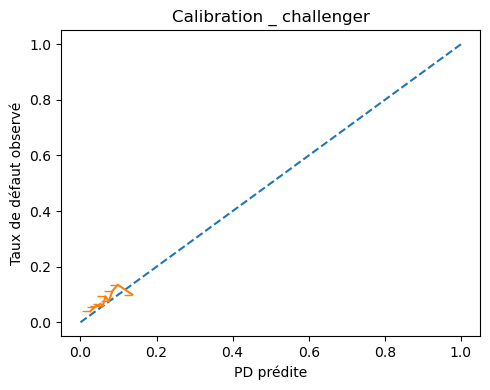

In [55]:
# ==================================================================
# 4) Calibration plots (Reliability curves)
# ==================================================================

def plot_calibration(y_true, y_score, title: str):
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=10, strategy="quantile")
    plt.figure(figsize=(5, 4))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(prob_pred, prob_true, marker= 0)
    plt.xlabel("PD prédite")
    plt.ylabel("Taux de défaut observé")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Exemple d'appel (décommente pour visualiser dans un notebook)
# plot_calibration(y_test, pred_champ, "Calibration - Champion")
plot_calibration(y_test, pred_chall, "Calibration _ challenger")

### Comment lire le graphique

1. **La diagonale pointillée (y=x)**

C’est la calibration parfaite :

Si le modèle prédit 0.3 (30 % de risque), alors en réalité 30 % des clients font défaut.

C’est l’objectif idéal.

2. **La courbe (prob_pred vs prob_true)**

- Chaque point représente un bin de clients ayant des probabilités similaires.

- Position d’un point :

    - Abscisse = probabilité prédite moyenne dans ce bin.
    - Ordonnée = taux de défaut réellement observé.

- Interprétation des écarts

    - Courbe au-dessus de la diagonale : le modèle sous-estime le risque (il prédit trop bas). → Exemple : le modèle dit 20 %, mais en réalité 30 % font défaut.

    - Courbe en dessous de la diagonale : le modèle surestime le risque (il prédit trop haut).→ Exemple : le modèle dit 80 %, mais seulement 60 % font défaut.

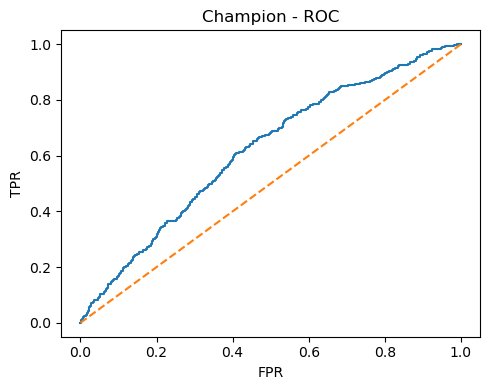

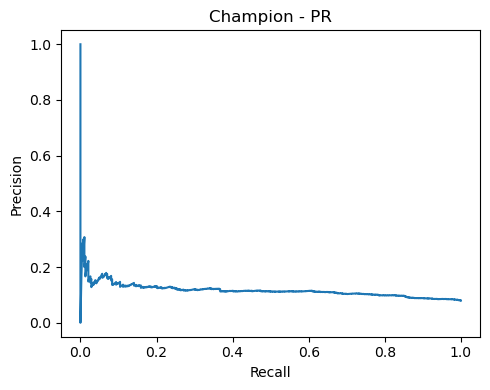

In [56]:
# =================================================================
# 5) Courbes ROC & PR
# =================================================================

def plot_roc_pr(y_true, y_score, title_prefix: str):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} - ROC")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} - PR")
    plt.tight_layout()
    plt.show()

plot_roc_pr(y_test, pred_champ, "Champion")
# plot_roc_pr(y_test, pred_chall, "Challenger")

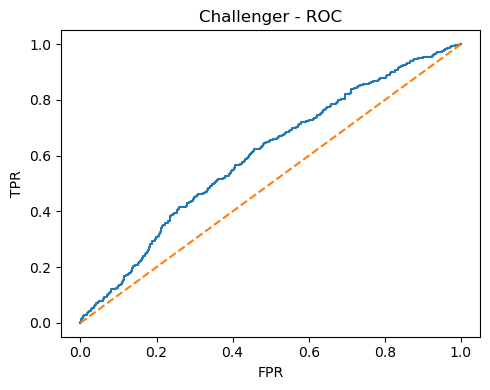

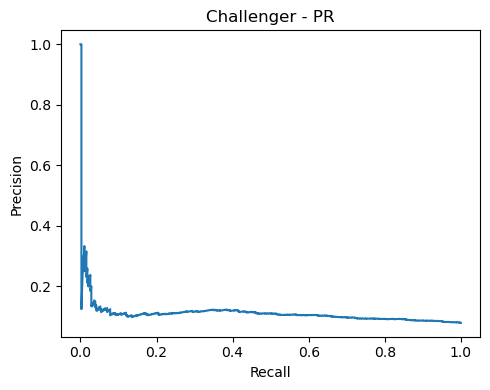

In [57]:
plot_roc_pr(y_test, pred_chall, "Challenger")

In [58]:
# =====================================================================
# 6) Backetesting: metriques par mois (sur la période de test)
# =====================================================================
def backtest_by_month(model, test_df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    out = []
    for m, g in test_df.groupby(test_df["date"].dt.to_period("M")):
        if g["default"].nunique() < 2:
            continue  
        y = g["default"].values 
        p = model.predict_proba(g[features])[:, 1]
        mtr = summarize_metrics(y, p)
        mtr["month"] = str(m)
        out.append(mtr)
    return pd.DataFrame(out).sort_values("month")

bt_champ = backtest_by_month(champion, test_df, features) 
bt_chall = backtest_by_month(challenger, test_df, features) 
print("=== Backtesting mensuel (extrait) - Chapion ===")
print(bt_champ.head())
print("=== Backtesting mensuel (extrait) - challenger ====")
print(bt_chall.head())

=== Backtesting mensuel (extrait) - Chapion ===
        AUC      Gini        KS     Brier    month
0  0.637747  0.275494  0.241982  0.061890  2023-07
1  0.637749  0.275499  0.269639  0.081495  2023-08
2  0.681701  0.363401  0.321659  0.075163  2023-09
3  0.541190  0.082380  0.143439  0.073151  2023-10
4  0.593031  0.186061  0.183606  0.072081  2023-11
=== Backtesting mensuel (extrait) - challenger ====
        AUC      Gini        KS     Brier    month
0  0.613519  0.227038  0.206037  0.062644  2023-07
1  0.629308  0.258616  0.243956  0.081165  2023-08
2  0.638248  0.276496  0.270958  0.076407  2023-09
3  0.559475  0.118951  0.126489  0.073323  2023-10
4  0.575779  0.151558  0.166936  0.072509  2023-11


In [60]:
# ==================================================================
# 7) Stabilité des coefficients (Champion - Logit) sur fénetres roulantes 
# ==================================================================

def rolling_coef_stablity(train_df: pd.DataFrame, features: List[str], window_months: int = 12) -> pd.DataFrame:
    months = sorted(train_df["date"].dt.to_period("M").unique())
    rows = []
    for i in range(len(months) - window_months + 1):
        start, end  = months[i], months[i + window_months - 1]
        mask = (train_df["date"].dt.to_period("M") >= start) & (train_df["date"].dt.to_period("M") <= end)
        sub = train_df[mask]
        if sub["default"].nunique() < 2:
            continue 
        x, y = sub[features], sub["default"]
        m = LogisticRegression(max_iter=2000).fit(x, y)
        row = {"window": f"{start}_{end}"}
        row.update({f"coef_{f}": c for f, c in zip(features, m.coef_[0])})
        row["intercept"] = m.intercept_[0]
        rows.append(row)
    return pd.DataFrame(rows) 

coef_track = rolling_coef_stablity(train_df, features, window_months=12)
print("=== Stabilié des coefficients (apercu)==")
print(coef_track.head())



=== Stabilié des coefficients (apercu)==
            window  coef_revenu  coef_age  coef_anciennete  coef_dti  \
0  2021-01_2021-12    -0.000248 -0.003046        -0.018178  0.965942   
1  2021-02_2022-01    -0.000258 -0.002743        -0.015279  0.977519   
2  2021-03_2022-02    -0.000268 -0.002645        -0.016031  1.032229   
3  2021-04_2022-03    -0.000244 -0.003198        -0.015848  1.200123   
4  2021-05_2022-04    -0.000241 -0.005321        -0.014660  1.212740   

   coef_unemployement  intercept  
0            0.013723  -1.991978  
1            0.031887  -2.151588  
2            0.090163  -2.473273  
3            0.145720  -2.965930  
4            0.057654  -2.324898  


### Le but: vérifier la stabilité des coefficients :

Suivre l’évolution des coefficients d’un modèle de régression logistique (ici ton “champion”) sur des fenêtres temporelles roulantes de 12 mois.

**Cela permet de vérifier si la relation entre les variables et la cible est stable dans le temps**, ou si elle dérive (concept drift).

### Interprétation :

- Si les coefficients restent stables dans le temps, ton modèle est robuste.

- Si un coefficient change fortement (par ex. coef_dti passe de 1.2 à 0.4), cela signale un drift de variable → le lien entre la variable et le défaut évolue.

### Definition d'une fenetre roulante

Une fenêtre roulante (rolling window en anglais) est une période de temps fixe qu’on fait glisser progressivement sur une série temporelle pour calculer une statistique, entraîner un modèle, ou mesurer un indicateur.

Concrètement :

- Tu définis une fenêtre de longueur fixe (par ex. 12 mois).

- Tu fais ton calcul (moyenne, entraînement d’un modèle, KS, etc.) sur ces 12 mois.

Ensuite, tu déplaces la fenêtre d’un mois (ou d’un jour, selon la granularité) et tu recommences.

In [61]:
import matplotlib.pyplot as plt

def plot_coef_stability(coef_track: pd.DataFrame, features: list):
    plt.figure(figsize=(10, 6))
    
    # Boucle sur chaque feature pour tracer sa courbe
    for f in features:
        plt.plot(
            coef_track["window"], 
            coef_track[f"coef_{f}"], 
            marker="o", 
            label=f
        )
    
    # On peut aussi tracer l'intercept si besoin
    plt.plot(
        coef_track["window"], 
        coef_track["intercept"], 
        marker="x", 
        linestyle="--", 
        label="Intercept"
    )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Fenêtres temporelles (roulantes)")
    plt.ylabel("Coefficient estimé")
    plt.title("Stabilité des coefficients logistiques dans le temps")
    plt.legend()
    plt.tight_layout()
    plt.show()


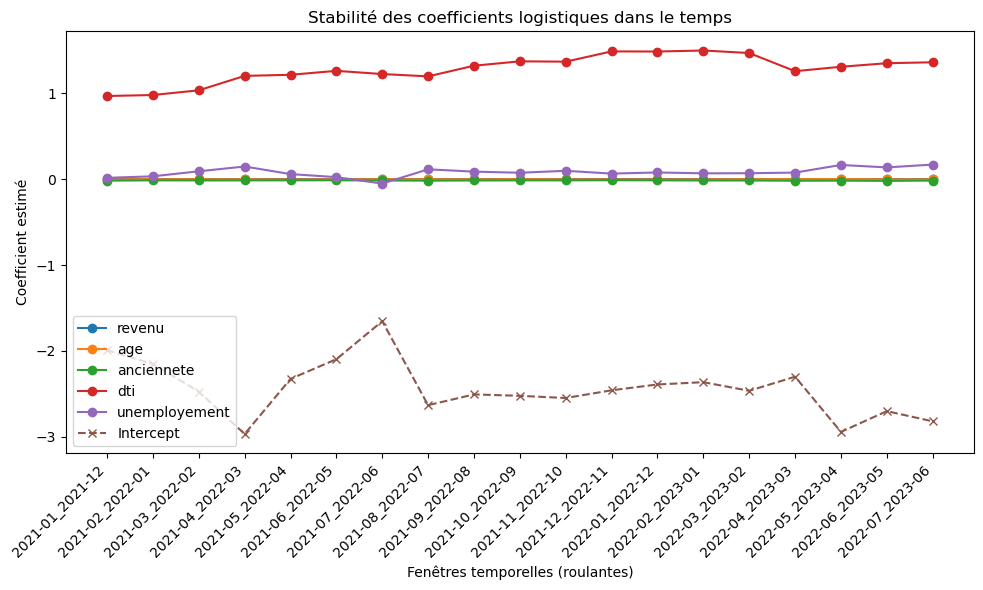

In [64]:
plot_coef_stability(coef_track, features)

In [66]:
# ==========================================================================
# 8) Stress testing (sensibilité aux chocs)
# ==========================================================================
@dataclass
class Shock:
    name: str
    pct_dti: float = 0.0      # +10% => 0.10
    pct_revenu: float = 0.0   # -15% => -0.15
    pp_unemp: float = 0.0     # +3 points de pourcentage

def apply_shock(df: pd.DataFrame, shock: Shock) -> pd.DataFrame:
    shocked = df.copy()
    if shock.pct_dti != 0:
        shocked["dti"] = (shocked["dti"] * (1 + shock.pct_dti)).clip(0, 1)
    if shock.pct_revenu != 0:
        shocked["revenu"] = shocked["revenu"] * (1 + shock.pct_revenu)
    if shock.pp_unemp != 0:
        shocked["unemployemet"] = shocked["unemployement"] + shock.pp_unemp
    return shocked

def stress_report(model, base_df: pd.DataFrame, features: List[str], shocks: List[Shock]) -> pd.DataFrame:
    base_pd = model.predict_proba(base_df[features])[:, 1]
    out = [{"scenario": "Base", "PD_moy": base_pd.mean(), "AUC":roc_auc_score(base_df["default"], base_pd)}]
    for s in shocks:
        shocked = apply_shock(base_df, s)
        pd_s = model.predict_proba(shocked[features])[:, 1]
        out.append({
            "scenario": s.name,
            "PD_moy": pd_s.mean(),
            "AUC": roc_auc_score(base_df["default"], pd_s),
        })
    return pd.DataFrame(out)


shocks = [
    Shock(name="DTI + 10%", pct_dti=0.10),
    Shock(name="Revenu - 15%", pct_revenu=-0.15),
    Shock(name="Chomage +3pp", pp_unemp=3.0),
    Shock(name="Combo sévère", pct_dti=0.10, pct_revenu=-0.15, pp_unemp=3.0),
]

stress_champ = stress_report(champion, test_df, features, shocks)
stress_chall = stress_report(challenger, test_df, features, shocks)

print("=== Stress testing - Champion ===")
print(stress_champ)
print("=== Stress testing - Challenger ===")
print(stress_chall)


=== Stress testing - Champion ===
       scenario    PD_moy       AUC
0          Base  0.072221  0.619044
1     DTI + 10%  0.076370  0.617351
2  Revenu - 15%  0.080968  0.616857
3  Chomage +3pp  0.072221  0.619044
4  Combo sévère  0.085567  0.614751
=== Stress testing - Challenger ===
       scenario    PD_moy       AUC
0          Base  0.068074  0.599340
1     DTI + 10%  0.072025  0.606179
2  Revenu - 15%  0.076675  0.595014
3  Chomage +3pp  0.068074  0.599340
4  Combo sévère  0.081408  0.603955


In [67]:
# =====================================================================
# 9) Population Stability Index (PSI) en bonus
# =====================================================================

def psi(expected: np.ndarray, actual: np.ndarray, bins: int = 10) -> float:
    q = np.linspace(0, 1, bins + 1)
    cuts = np.quantile(expected, q)
    # Evite les doublons de quantiles 
    cuts = np.unique(cuts)
    exp_hist, _ = np.histogram(expected, bins=cuts)
    act_hist, _ = np.histogram(actual, bins=cuts)
    exp_pct = exp_hist / exp_hist.sum()
    act_pct = act_hist / max(1, act_hist.sum())
    exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-6, act_pct)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

# PSI entre train et test pour le score champion
score_train = champion.predict_proba(x_train)[:, 1]
score_test = pred_champ 
psi_value = psi(score_train, score_test)
print(f"PSI(Champion score Train vs Test): {psi_value:.4f}")

PSI(Champion score Train vs Test): 0.0014


### Objectif du PSI

Le PSI (Population Stability Index) mesure dans quelle mesure la distribution d’une variable (ex: score modèle) a changé entre deux populations :

expected = population de référence (souvent le train ou un ancien batch).

actual = nouvelle population (souvent le test, une fenêtre temporelle plus récente, ou la prod).

- En clair : c’est un test de stabilité des distributions.

Si PSI est faible → la distribution est stable, pas de dérive.

Si PSI est élevé → la population a changé → risque de drift → ton modèle peut devenir moins fiable.

In [68]:
# =============================================================
# 10) Résumé final des métriques clés 
# =============================================================

def print_summary_table():
    rows = []
    rows.append({"Modèle": "Champion", **{k: round(v, 4) for k, v in metrics_champ.items()}})
    rows.append({"Modèle": "Challenger", **{k: round(v, 4) for k, v in metrics_chall.items()}})
    summary = pd.DataFrame(rows)
    print("== Résumé OOT ===")
    print(summary.to_string(index=False))

print_summary_table()

== Résumé OOT ===
    Modèle    AUC   Gini     KS  Brier
  Champion 0.6190 0.2381 0.2013 0.0728
Challenger 0.5993 0.1987 0.1654 0.0732


In [69]:
# --- Notes d'utilisation ---
# - Pour visualiser les graphs: décommentez les appels plot_*.
# - Adaptez les 'features' à votre dataset réel.
# - Le backtesting peut etre affiné par portefeuille/ segment.
# - Le stress testing peut integrer des scénarios macro (ex: choc récesssion) et seuils réglementaires.
